Faster R-CNN

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import torch
# import torchmetrics
import torchvision
from torchvision import transforms
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image


In [ ]:
!unzip Custom.zip -d CT
print("Done Unzipping!")

Archive:  Custom.zip
   creating: CT/Custom/
   creating: CT/Custom/test/
   creating: CT/Custom/test/images/
  inflating: CT/Custom/test/images/5PN77-67001-0489f987-51ea-11f1-80de-683e263742df.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-04e98cf7-51ea-11f1-b313-683e263742df.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-04e98cf7-51ea-11f1-b313-683e263742df_jpg.rf.yfpBhhPWeHMYGJELtoze.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-0be71df0-51ea-11f1-801e-683e263742df.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-0c5bff09-51ea-11f1-a74c-683e263742df.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-0d5b86d0-51ea-11f1-b3d0-683e263742df.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-0e2e879a-51ea-11f1-b4dc-683e263742df.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-113f0155-51ea-11f1-8e51-683e263742df.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-1b2769e1-51ea-11f1-84fb-683e263742df.jpg  
  inflating: CT/Custom/test/images/5PN77-67001-1be5e

In [ ]:
n_classes = 4 + 1

In [ ]:
from torchvision.transforms import v2
from torchvision import tv_tensors
data_transform = transforms.Compose([
    transforms.ToTensor()
])

transforms2 = v2.Compose([
    v2.ConvertBoundingBoxFormat("xyxy"),
    v2.ToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((640, 640)),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


YOLO 양식 txt파일은 [중심X, 중심Y, 가로폭, 세로폭]
Faster R-CNN 은 [좌상단X, 좌상단Y, 우하단X, 우하단Y]

In [ ]:
def xywh_xyxy(box, img_w, img_h):
  cx, cy, w, h = box

  cx_pixel = cx * img_w
  cy_pixel = cy * img_h
  w_pixel  = w  * img_w
  h_pixel  = h  * img_h

  x1 = cx_pixel - (w_pixel/2)
  y1 = cy_pixel - (h_pixel/2)
  x2 = cx_pixel + (w_pixel/2)
  y2 = cy_pixel + (h_pixel/2)

  return [x1, y1, x2, y2]

In [ ]:
import os

class ObjectDetectionDataset(torch.utils.data.Dataset):
  def __init__(self, image_dir, label_dir, transform):
    self.image_dir = image_dir
    self.label_dir = label_dir
    self.image_info = os.listdir(image_dir)
    self.transform = transform

  def __len__(self):
    return len(self.image_info)

  def __getitem__(self, idx):
    image_id = self.image_info[idx]
    image_path = os.path.join(self.image_dir, image_id)

    ext = os.path.splitext(image_id)[1]
    label_path = os.path.join(self.label_dir, image_id.replace(ext, '.txt'))

    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    labels, bboxes = [], []
    if os.path.exists(label_path):
      with open(label_path, 'r') as f:
        for lines in f.readlines():
          parts = lines.split()
          if len(parts) < 5:
            continue

          label, boxes = parts[0], parts[1:]
          label = int(label) + 1
          boxes = [float(box) for box in boxes[:4]]
          # rcnn_box = xywh_xyxy(boxes, img_w, img_h)
          labels.append(label)
          bboxes.append(boxes)

    if bboxes == []:
      bboxes = [[1.0, 1.0, 5.0, 5.0]]
      labels = [0]


    # bboxes = torchvision.ops.box_convert(boxes, in_fmt="cxcywh", out_fmt="xyxy")

    bboxes = tv_tensors.BoundingBoxes(bboxes, format="cxcywh", canvas_size=(640, 640))
    image, bboxes = self.transform(image, bboxes)

    boxes = torch.as_tensor(bboxes*640, dtype=torch.float32)
    labels = torch.as_tensor(labels, dtype=torch.int64)



    target = {}
    target["boxes"]  = boxes
    target["labels"] = labels

    # image = self.transform(image)
    return image, target

  def collate_fn(self, batch):
    return tuple(zip(*batch))

In [ ]:

train_data = ObjectDetectionDataset('CT/Custom/train/images', 'CT/Custom/train/labels', data_transform)
validation_data = ObjectDetectionDataset('CT/Custom/valid/images', 'CT/Custom/valid/labels', data_transform)


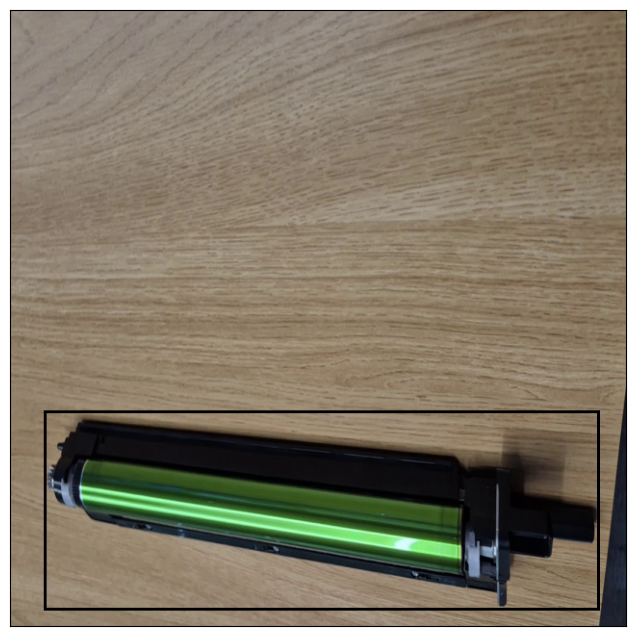

In [ ]:
import numpy as np
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

train_data = ObjectDetectionDataset('CT/Custom/train/images', 'CT/Custom/train/labels', transforms2)
validation_data = ObjectDetectionDataset('CT/Custom/valid/images', 'CT/Custom/valid/labels', transforms2)


def show(imgs):
  if not isinstance(imgs, list):
    imgs = [imgs]
  fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=(8 , 8))
  for i, img in enumerate(imgs):
    img = img.detach()
    img = F.to_pil_image(img)
    axs[0, i].imshow(np.asarray(img))
    axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
  plt.show()

img, target = train_data[200]

img_uint8 = (img * 255).to(torch.uint8)

result = draw_bounding_boxes(img_uint8, target['boxes'], width=3)

show(result)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=16,
    shuffle=True,
    collate_fn=train_data.collate_fn
    )

validation_loader = DataLoader(
    validation_data,
    batch_size=16,
    shuffle=False,
    collate_fn=validation_data.collate_fn
    )

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def get_model():
  weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
  model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)

  in_features = model.roi_heads.box_predictor.cls_score.in_features
  model.roi_heads.box_predictor = FastRCNNPredictor(in_features, n_classes)
  return model

In [ ]:
def train_batch(model, optimizer, batch):
  model.train()
  images, targets = batch
  images = [image.to(device) for image in images]
  targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
  optimizer.zero_grad()
  losses = model(images, targets)
  loss = sum(loss for loss in losses.values())
  loss.backward()
  optimizer.step()
  return loss.item(), {k: v.item() for k, v in losses.items()}

@torch.no_grad()
def validate_batch(model, batch):
  model.train()
  images, targets = batch
  images = [image.to(device) for image in images]
  targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
  optimizer.zero_grad()
  losses = model(images, targets)
  loss = sum(loss for loss in losses.values())
  return loss.item(), {k: v.item() for k, v in losses.items()}

In [ ]:
model = get_model().to(device)

for name, param in model.named_parameters():
  if 'backbone' in name:
    param.requires_grad = False
  else:
    param.requires_grad = True

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
n_epochs = 20

In [ ]:
for epoch in range(n_epochs):
  print(f"====== Epoch {epoch + 1} / {n_epochs} =====")

    # --- [Training Phase] ---
  train_loss_sum = 0.0
  train_batches = len(train_loader)

  for ix, batch in enumerate(train_loader):
    loss, losses = train_batch(model, optimizer, batch)
    train_loss_sum += loss
    print(ix + 1, loss)

    if (ix + 1) % 10 == 0 or (ix + 1) == train_batches:
      print(f"  Training Batch [{ix + 1}/{train_batches}] | Batch Loss: {loss:.4f}")

  epoch_train_loss = train_loss_sum / train_batches


  # --- [Validation Phase] ---
  val_loss_sum  = 0.0
  val_batches = len(validation_loader)

  for ix, batch in enumerate(validation_loader):
    loss, losses = validate_batch(model, batch)
    val_loss_sum += loss

  epoch_val_loss = val_loss_sum / val_batches

  scheduler.step()

  print(f"▶ Epoch {epoch + 1} Result Summary")
  print(f"  -> Average Train Loss      : {epoch_train_loss:.4f}")
  print(f"  -> Average Validation Loss : {epoch_val_loss:.4f}")
  print(f"  -> Current Learning Rate   : {scheduler.get_last_lr()[0]}")
  print()



====== Epoch 1 / 20 =====
1 1.8799707889556885
2 0.41154250502586365
3 0.4045555889606476


Detected Objects Count: 3
Labels Result: [1, 1, 1]
Confidence Scores Result: [0.47668927907943726, 0.4537280797958374, 0.4469013214111328]


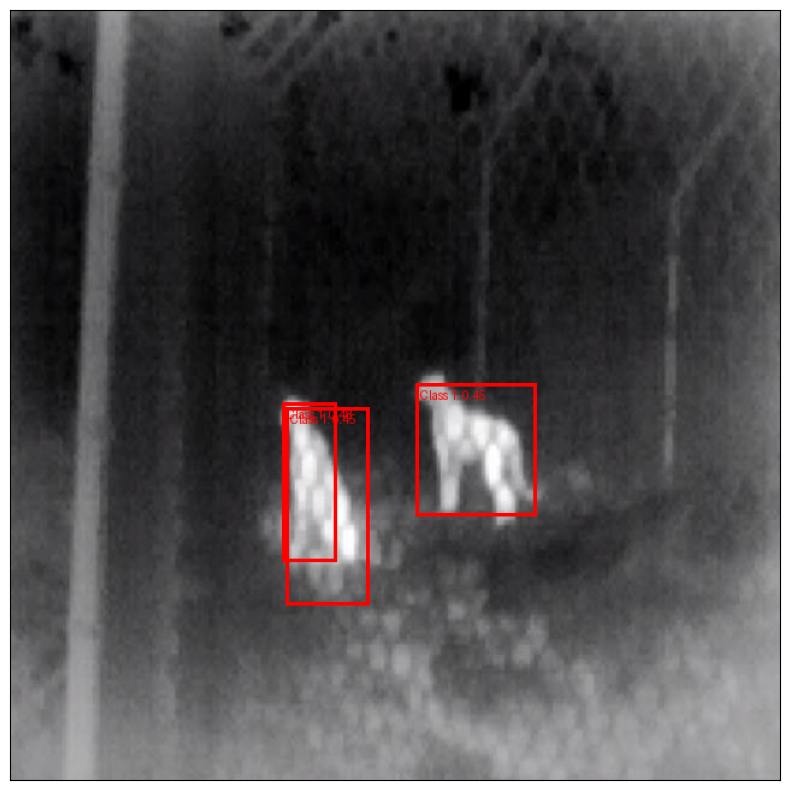

In [ ]:
# Visualization helper function
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=(10, 10))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    plt.show()

# 1. Switch model to evaluation mode
model.eval()

# 2. Load and pre-process the test image
test_image_path = '/content/custom/test/images/PIR-206_13_mov-7_jpg.rf.5d91441efa370b0657e069b9661cc1b9.jpg'
test_image = Image.open(test_image_path).convert('RGB')
transformed_image = data_transform(test_image) # Tensor conversion (0~1 float)

# 3. Disable gradient computation and safely perform inference
with torch.no_grad():
    prediction = model([transformed_image.to(device)])[0]

# 4. Extract output values
labels = prediction['labels'].cpu()
boxes = prediction['boxes'].cpu()
scores = prediction['scores'].cpu()

# 💡 [Core Configuration] Filter detections that meet or exceed the specified threshold
threshold = 0.4
high_score_idx = torch.where(scores >= threshold)[0]

filtered_boxes = boxes[high_score_idx]
filtered_labels = labels[high_score_idx]
filtered_scores = scores[high_score_idx]

print(f"Detected Objects Count: {len(filtered_boxes)}")
print("Labels Result:", filtered_labels.tolist())
print("Confidence Scores Result:", filtered_scores.tolist())

# 5. Convert original image back to uint8 tensor format to draw bounding boxes
img_uint8 = (transformed_image * 255).to(torch.uint8)

if len(filtered_boxes) > 0:
    # Format labels inside the bounding boxes (e.g., "Class 1: 0.94")
    box_labels = [f"Class {lbl}: {scr:.2f}" for lbl, scr in zip(filtered_labels, filtered_scores)]

    result = draw_bounding_boxes(img_uint8, filtered_boxes, labels=box_labels, width=3, colors="red")
    show(result)
else:
    print("❌ No detection results met the specified threshold criteria.")
    show(img_uint8)

🔍 Initializing diagnostic evaluation over 14 test targets... (Threshold: 0.5)

[1/14] File: IMG_0028_jpeg_jpg.rf.890b13f9105ecbb812787048f9df8def.jpg
   ▶ ❌ No target detected (Max candidate score: 0.4918)
------------------------------------------------------------
[2/14] File: IMG_0040_jpeg_jpg.rf.4b7bade8d513fbcff93e9cf73bf7509c.jpg
   ▶ ❌ No target detected (Max candidate score: 0.3097)
------------------------------------------------------------
[3/14] File: PIR-206_0_mov-10_jpg.rf.31f45492a7348f7e3ba54d7253ee50a7.jpg
   ▶ ❌ No target detected (Max candidate score: 0.2959)
------------------------------------------------------------
[4/14] File: PIR-206_0_mov-1_jpg.rf.4d3b53831f366b5a49626f9cbfb45d17.jpg
   ▶ ❌ No target detected (Max candidate score: 0.4257)
------------------------------------------------------------
[5/14] File: PIR-206_13_mov-7_jpg.rf.5d91441efa370b0657e069b9661cc1b9.jpg
   ▶ ❌ No target detected (Max candidate score: 0.4767)
----------------------------------

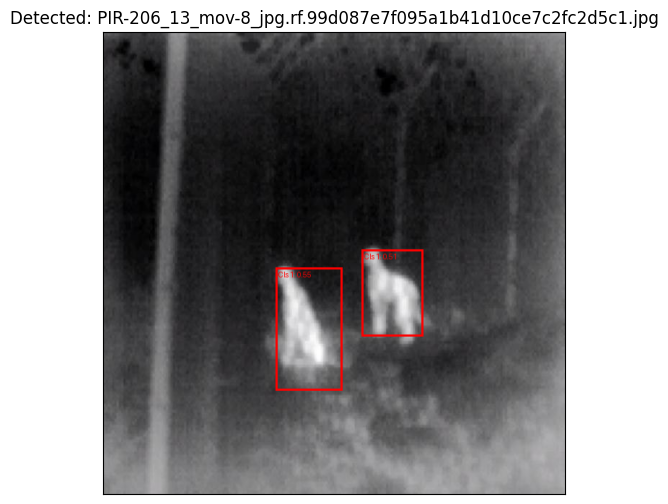

------------------------------------------------------------
[7/14] File: PIR-206_13_mov-9_jpg.rf.0f4ac5016c28e2f433a26cff4a50f6f5.jpg
   ▶ 🎯 Detection Success! Object Count: 1
      - Object 1: Label 1 (Confidence: 0.5206)


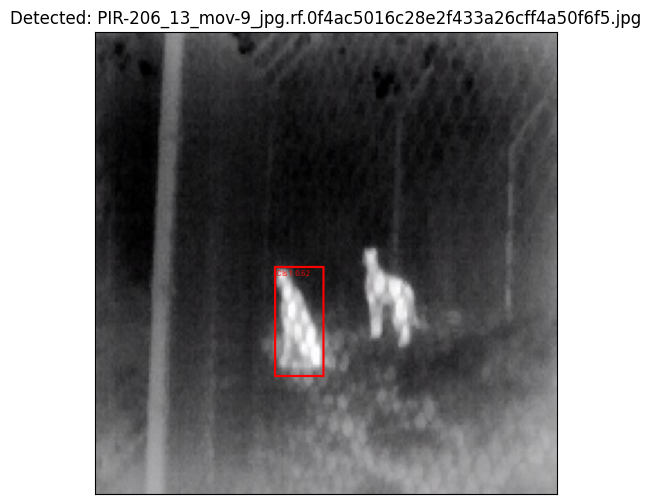

------------------------------------------------------------
[8/14] File: PIR-206_19_mov-10_jpg.rf.665eac0c029890c302d73618c7afe196.jpg
   ▶ ❌ No target detected (Max candidate score: 0.4872)
------------------------------------------------------------
[9/14] File: PIR-206_19_mov-12_jpg.rf.44d4a76e8b89b753b881fcf0bad15896.jpg
   ▶ 🎯 Detection Success! Object Count: 1
      - Object 1: Label 1 (Confidence: 0.5207)


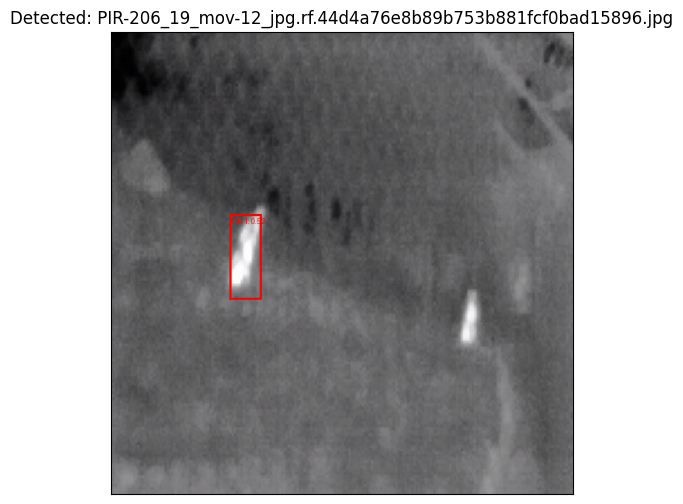

------------------------------------------------------------
[10/14] File: PIR-206_19_mov-5_jpg.rf.90d01e6d11cb253916dd09cf7c826573.jpg
   ▶ 🎯 Detection Success! Object Count: 2
      - Object 1: Label 1 (Confidence: 0.6036)
      - Object 2: Label 1 (Confidence: 0.5213)


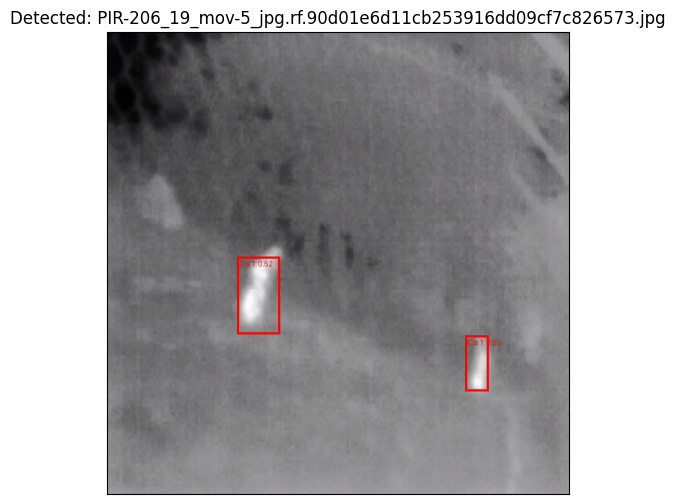

------------------------------------------------------------
[11/14] File: PIR-206_2_mov-5_jpg.rf.4a3b636182b79bdf498be008219f6176.jpg
   ▶ ❌ No target detected (Max candidate score: 0.3864)
------------------------------------------------------------
[12/14] File: PIR-206_6_mov-0_jpg.rf.6793ed1f27b699fc0351465f6bcbd681.jpg
   ▶ ❌ No target detected (Max candidate score: 0.4046)
------------------------------------------------------------
[13/14] File: PIR-206_8_mov-1_jpg.rf.667025d452716530864804ed8061de5d.jpg
   ▶ 🎯 Detection Success! Object Count: 1
      - Object 1: Label 1 (Confidence: 0.5350)


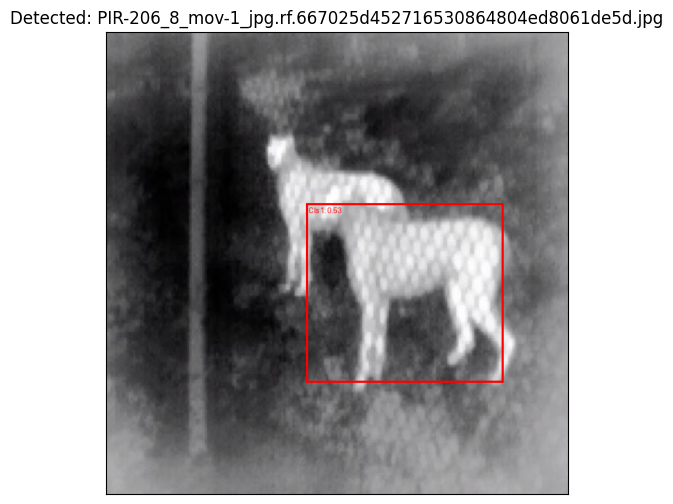

------------------------------------------------------------
[14/14] File: PIR-206_8_mov-3_jpg.rf.79e06a4bb72c322469d967db704bc43e.jpg
   ▶ 🎯 Detection Success! Object Count: 2
      - Object 1: Label 1 (Confidence: 0.5673)
      - Object 2: Label 1 (Confidence: 0.5019)


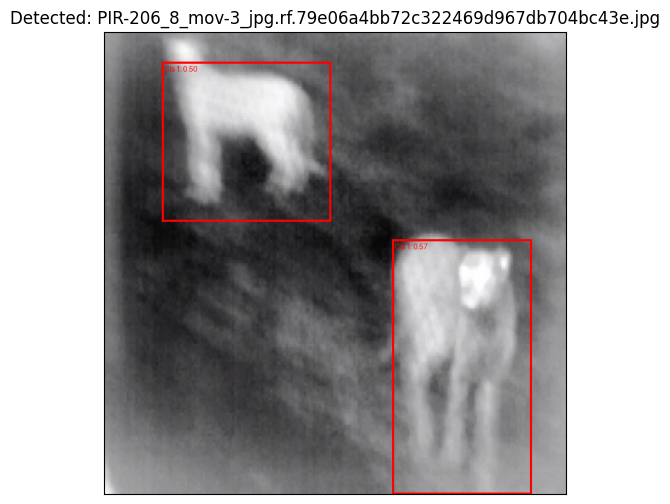

------------------------------------------------------------


In [ ]:
# 2. Define directory paths for test images and labels
test_image_dir = '/content/custom/test/images'
threshold = 0.5  # 💡 Confidence score threshold for filtering detections (adjust to 0.3 if needed)

if not os.path.exists(test_image_dir):
    print(f"❌ Target path not found: {test_image_dir}")
else:
    # Retrieve and sort the list of image files in the folder
    test_images = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"🔍 Initializing diagnostic evaluation over {len(test_images)} test targets... (Threshold: {threshold})\n")

    # 3. Iterate through all image files
    for idx, img_name in enumerate(test_images):
        img_path = os.path.join(test_image_dir, img_name)

        # Load the image and apply pre-processing transforms
        raw_image = Image.open(img_path).convert('RGB')
        transformed_image = data_transform(raw_image) # Apply the predefined ToTensor transform

        # Perform model inference
        with torch.no_grad():
            prediction = model([transformed_image.to(device)])[0]

        # Extract evaluation outputs
        labels = prediction['labels'].cpu()
        boxes = prediction['boxes'].cpu()
        scores = prediction['scores'].cpu()

        # Filter predictions that meet or exceed the specified threshold boundary
        high_score_idx = torch.where(scores >= threshold)[0]
        filtered_boxes = boxes[high_score_idx]
        filtered_labels = labels[high_score_idx]
        filtered_scores = scores[high_score_idx]

        # Print diagnostic results
        print(f"[{idx+1}/{len(test_images)}] File: {img_name}")
        if len(filtered_boxes) > 0:
            print(f"   ▶ 🎯 Detection Success! Object Count: {len(filtered_boxes)}")
            for i in range(len(filtered_boxes)):
                print(f"      - Object {i+1}: Label {filtered_labels[i].item()} (Confidence: {filtered_scores[i].item():.4f})")

            # Prepare visualization tensor data
            img_uint8 = (transformed_image * 255).to(torch.uint8)
            box_labels = [f"Cls {lbl}: {scr:.2f}" for lbl, scr in zip(filtered_labels, filtered_scores)]
            result = draw_bounding_boxes(img_uint8, filtered_boxes, labels=box_labels, width=3, colors="red")

            # Render and display the visualization plots
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.imshow(np.asarray(F.to_pil_image(result.detach())))
            ax.set_title(f"Detected: {img_name}")
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
            plt.show()
        else:
            # Print fallback logs indicating the highest candidate score found when detection fails
            max_score = scores.max().item() if len(scores) > 0 else 0.0
            print(f"   ▶ ❌ No target detected (Max candidate score: {max_score:.4f})")

        print("-" * 60)